# Adaboost


In [38]:
import pandas as pd
import numpy as np 
from mlxtend.plotting import plot_decision_regions

In [39]:
df=pd.DataFrame()

In [40]:
df['X1'] = [1,2,3,4,4,6,7,8,9,9]
df['X2'] = [5,3,6,3,1,9,4,8,9,2]
df['label'] = [1,1,0,0,0,1,0,0,1,0]

In [41]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,3,0
4,4,1,0
5,6,9,1
6,7,4,0
7,8,8,0
8,9,9,1
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

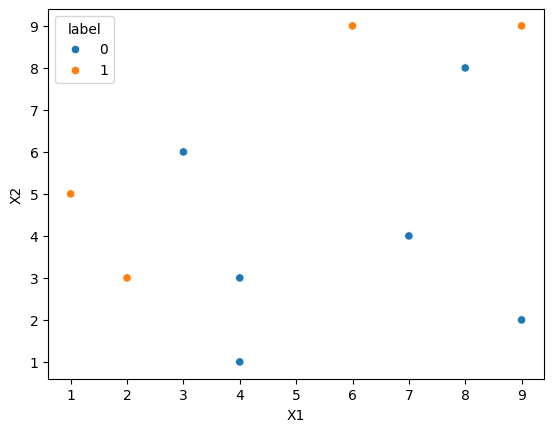

In [42]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [43]:
df['weights']=1/df.shape[0]
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,3,0,0.1
4,4,1,0,0.1
5,6,9,1,0.1
6,7,4,0,0.1
7,8,8,0,0.1
8,9,9,1,0.1
9,9,2,0,0.1


In [44]:
X=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [45]:
from sklearn.tree import DecisionTreeClassifier

In [46]:
dt1=DecisionTreeClassifier(max_depth=1)

In [47]:
dt1.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# tree plotting

[Text(0.5, 0.75, 'x[1] <= 8.5\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.25, 0.25, 'gini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.625, 0.5, '  False')]

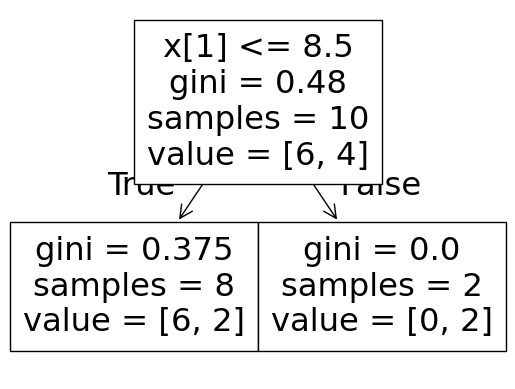

In [50]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

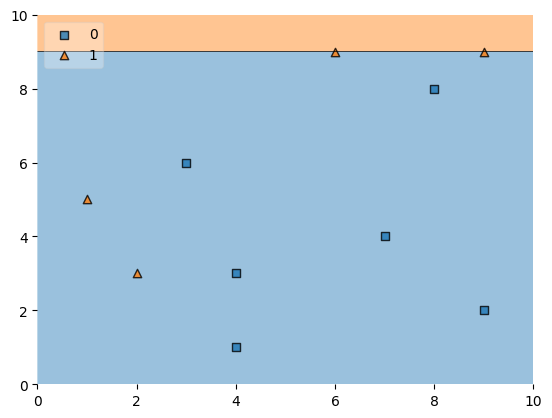

In [51]:
plot_decision_regions(X,y,clf=dt1,legend=2)

In [53]:
df['predict']=dt1.predict(X)
df

,X1,X2,label,weights,predict
0,1,5,1,0.1,0
1,2,3,1,0.1,0
2,3,6,0,0.1,0
3,4,3,0,0.1,0
4,4,1,0,0.1,0
5,6,9,1,0.1,1
6,7,4,0,0.1,0
7,8,8,0,0.1,0
8,9,9,1,0.1,1
9,9,2,0,0.1,0


In [56]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/error)

In [57]:
alpha1=calculate_model_weight(0.2)
alpha1

np.float64(0.6931471805599453)

In [58]:
df

,X1,X2,label,weights,predict
0,1,5,1,0.1,0
1,2,3,1,0.1,0
2,3,6,0,0.1,0
3,4,3,0,0.1,0
4,4,1,0,0.1,0
5,6,9,1,0.1,1
6,7,4,0,0.1,0
7,8,8,0,0.1,0
8,9,9,1,0.1,1
9,9,2,0,0.1,0


In [61]:

# weights update 
def updated_weights(row,alpha=0.693):
    if row['label']==row['predict']:
        return row['weights'] *np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)


In [62]:
df['updated_weights']=df.apply(updated_weights,axis=1)

In [63]:
df

,X1,X2,label,weights,predict,updated_weights
0,1,5,1,0.1,0,0.199971
1,2,3,1,0.1,0,0.199971
2,3,6,0,0.1,0,0.050007
3,4,3,0,0.1,0,0.050007
4,4,1,0,0.1,0,0.050007
5,6,9,1,0.1,1,0.050007
6,7,4,0,0.1,0,0.050007
7,8,8,0,0.1,0,0.050007
8,9,9,1,0.1,1,0.050007
9,9,2,0,0.1,0,0.050007


In [65]:
df['updated_weights'].sum()

np.float64(0.8000000086648471)